Determining Factors Impacting Academic Performance

In [3]:
# import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score

In [4]:
df = pd.read_csv("Students Database.csv")

In [5]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Score,Age,gender
0,7,99,Yes,9,1,91,19,female
1,4,82,No,4,2,65,20,female
2,8,51,Yes,7,2,45,18,female
3,5,52,Yes,5,2,36,20,male
4,7,75,No,8,5,66,20,male


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Hours Studied                     100 non-null    int64 
 1   Previous Scores                   100 non-null    int64 
 2   Extracurricular Activities        100 non-null    object
 3   Sleep Hours                       100 non-null    int64 
 4   Sample Question Papers Practiced  100 non-null    int64 
 5   Score                             100 non-null    int64 
 6   Age                               100 non-null    int64 
 7   gender                            100 non-null    object
dtypes: int64(6), object(2)
memory usage: 6.4+ KB


In [7]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Score,Age
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,5.320000,70.820000,6.460000,3.850000,57.190000,18.110000
std,2.639559,16.589141,1.811412,2.698204,19.253595,1.399098
min,1.000000,40.000000,4.000000,0.000000,15.000000,16.000000
25%,3.000000,59.000000,5.000000,2.000000,41.750000,17.000000
50%,5.000000,72.000000,6.000000,3.000000,59.000000,18.000000
75%,8.000000,83.000000,8.000000,6.000000,71.000000,19.000000
max,9.000000,99.000000,9.000000,9.000000,98.000000,20.000000


In [8]:
df.shape

(100, 8)

In [9]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Score                               0
Age                                 0
gender                              0
dtype: int64

In [10]:
df.select_dtypes(include='int64').nunique() 

Hours Studied                        9
Previous Scores                     49
Sleep Hours                          6
Sample Question Papers Practiced    10
Score                               49
Age                                  5
dtype: int64

In [11]:
column_names = df.columns.tolist()
print("Column Names:")
print(column_names)

Column Names:
['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced', 'Score', 'Age', 'gender']


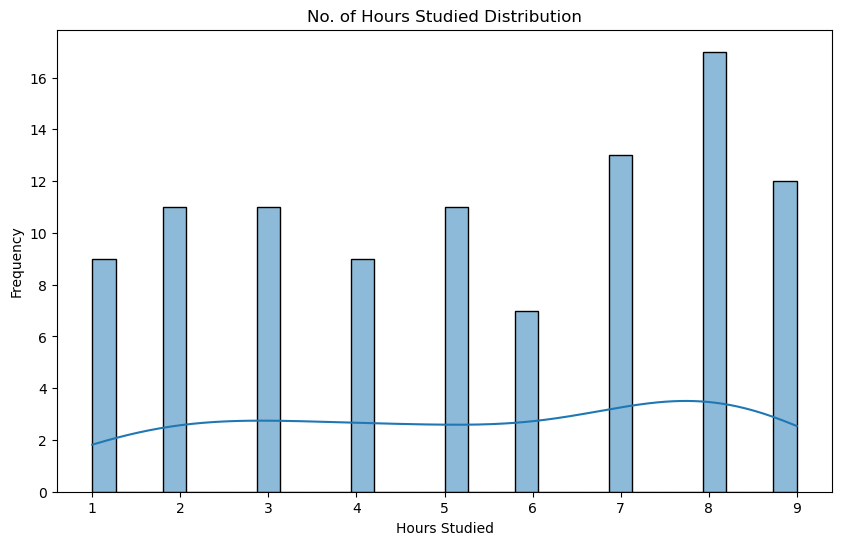

In [12]:
#No. of Hours Studied Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Hours Studied'], kde=True, bins=30)
plt.title('No. of Hours Studied Distribution')
plt.xlabel('Hours Studied')
plt.ylabel('Frequency')
plt.show()

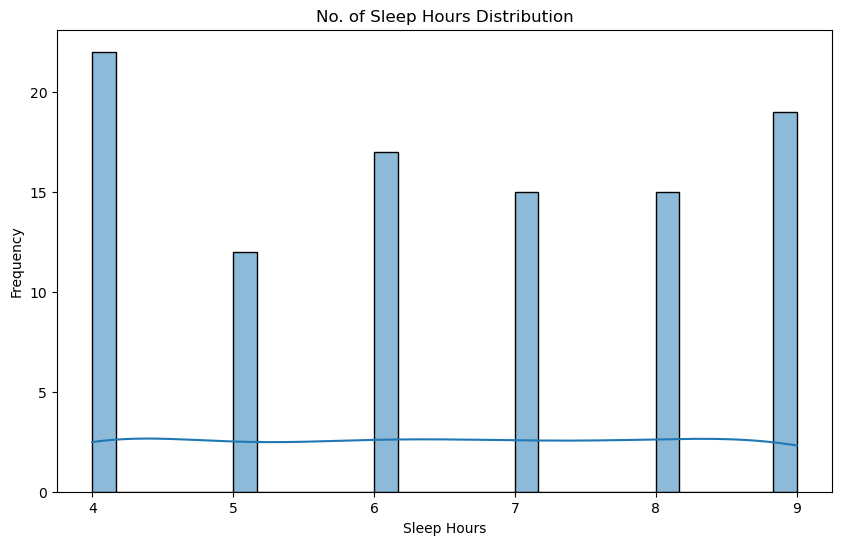

In [13]:
#No. of Sleep Hours Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Sleep Hours'], kde=True, bins=30)
plt.title('No. of Sleep Hours Distribution')
plt.xlabel('Sleep Hours')
plt.ylabel('Frequency')
plt.show()

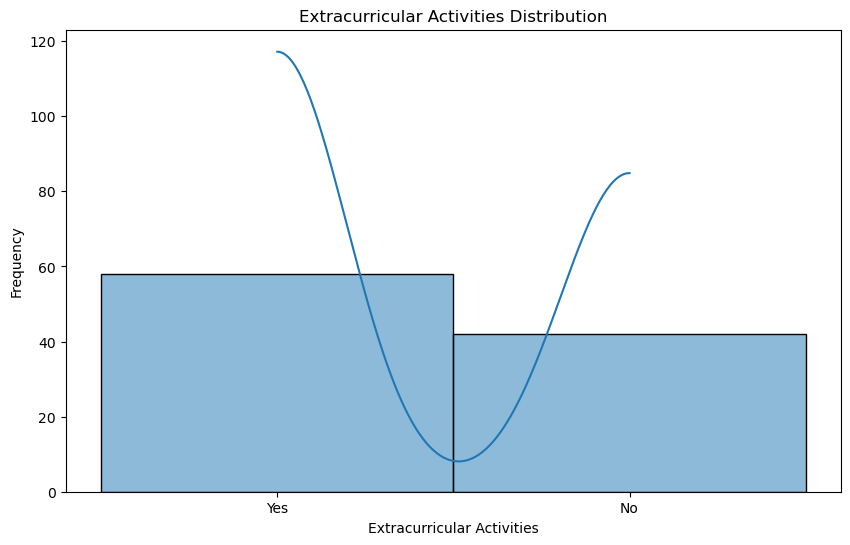

In [14]:
#Extracurricular Activities Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Extracurricular Activities'], kde=True, bins=30)
plt.title('Extracurricular Activities Distribution')
plt.xlabel('Extracurricular Activities')
plt.ylabel('Frequency')
plt.show()

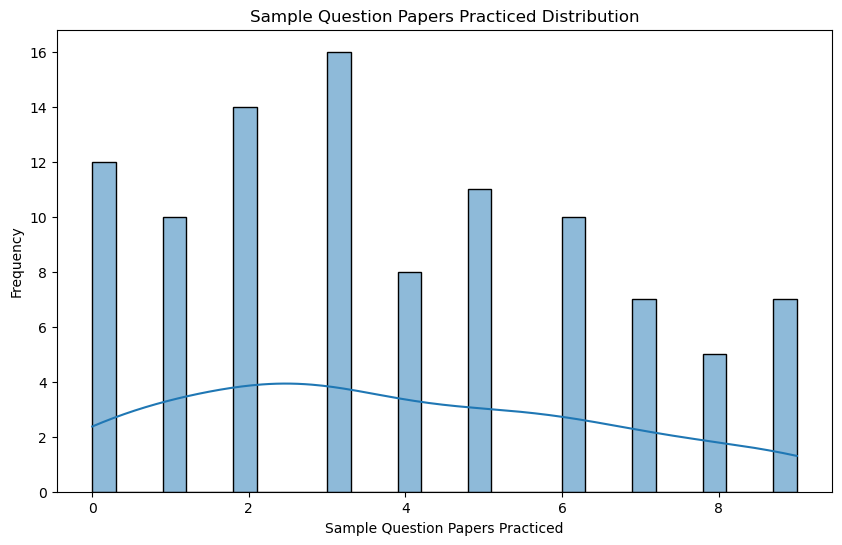

In [15]:
#Sample Question Papers Practiced Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Sample Question Papers Practiced'], kde=True, bins=30)
plt.title('Sample Question Papers Practiced Distribution')
plt.xlabel('Sample Question Papers Practiced')
plt.ylabel('Frequency')
plt.show()

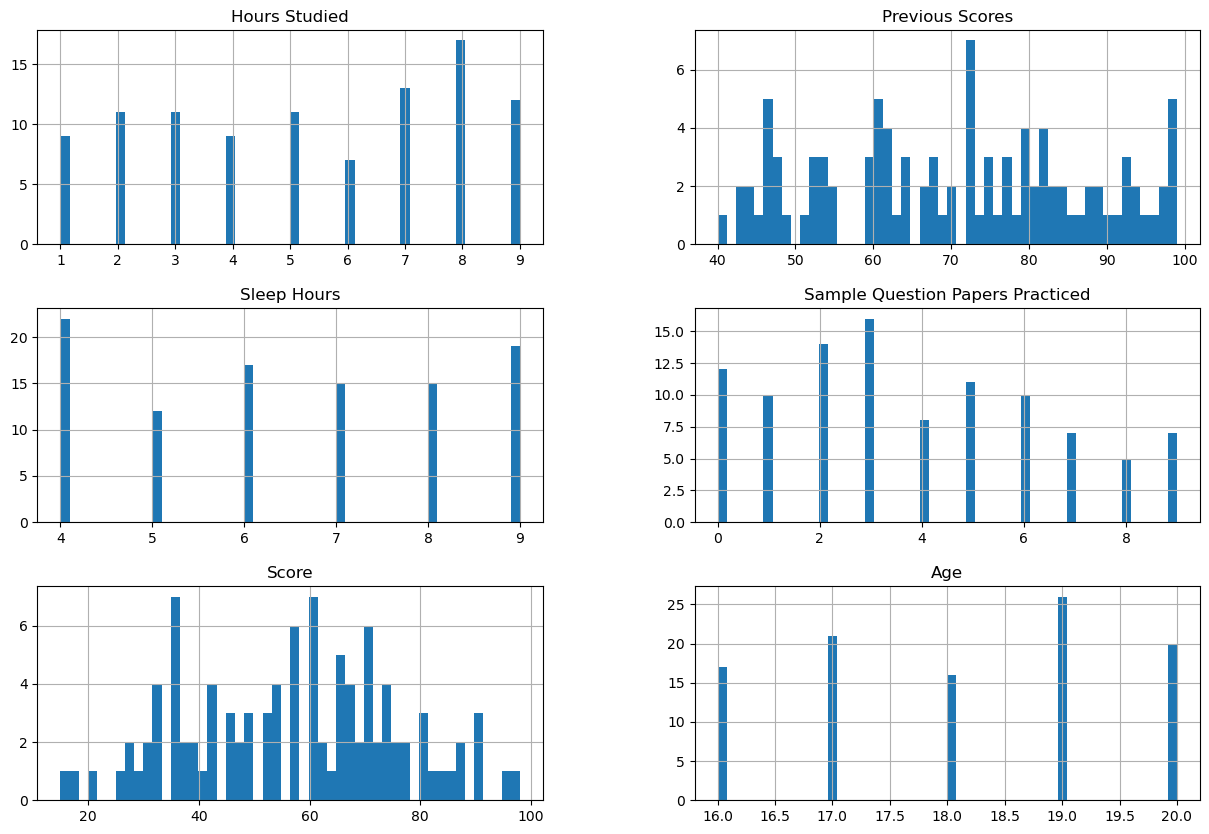

In [16]:
#Histograms for various (numeric) Factors
numeric_columns = df.select_dtypes(include=['int64'])
numeric_columns.hist(bins=50, figsize=(15, 10))
plt.show()

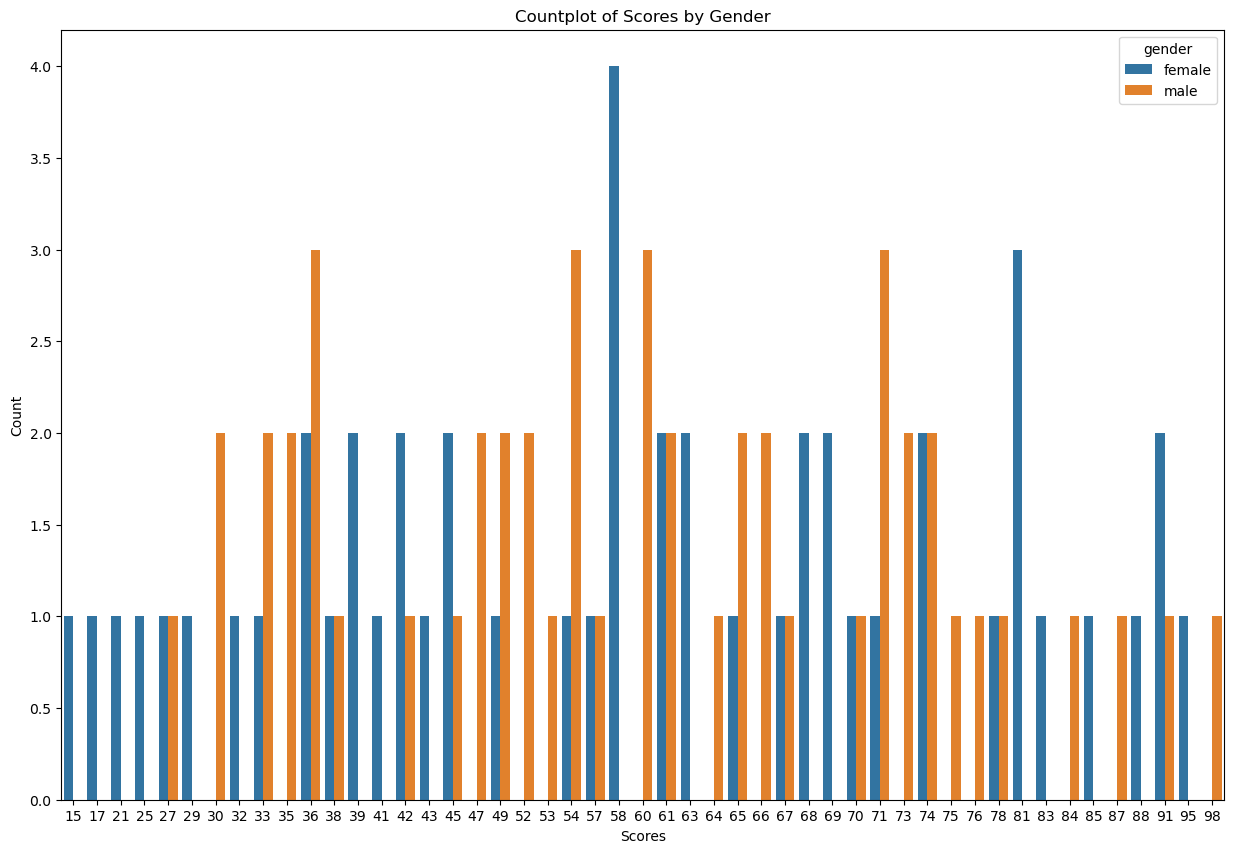

In [17]:
# Plot countplot for scores by Gender
plt.figure(figsize=(15, 10))
sns.countplot(x='Score', hue='gender', data=df)
plt.title('Countplot of Scores by Gender')
plt.xlabel('Scores')
plt.ylabel('Count')
plt.show()

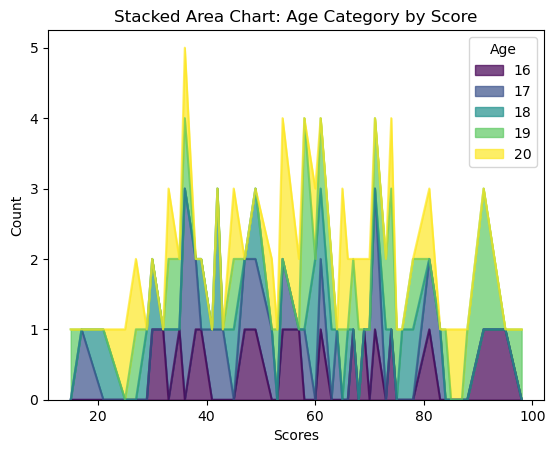

In [18]:
#Stacked Area Chart by Age Category by Scores
crosstab = pd.crosstab(df['Score'],df['Age'])
crosstab.plot(kind='area', colormap='viridis', alpha=0.7, stacked=True)
plt.title('Stacked Area Chart: Age Category by Score')
plt.xlabel('Scores')
plt.ylabel('Count')
plt.show()

Heatmap of Correlation

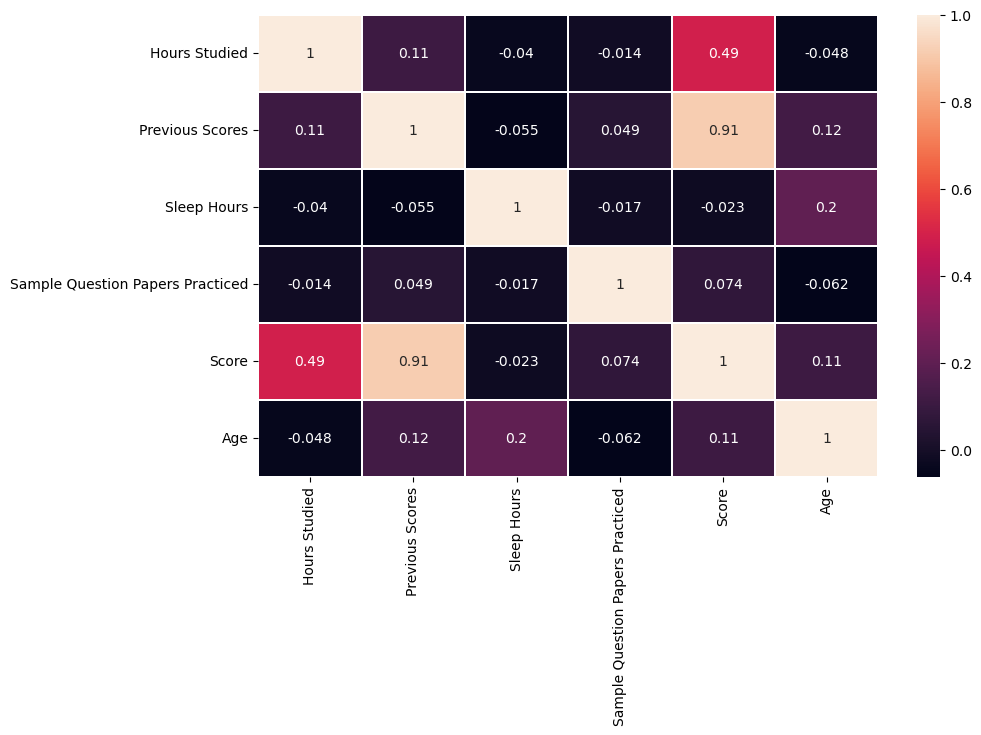

In [20]:
# first visualize correlation matrix between numerical columns
plt.figure(figsize = (10,6))
sns.heatmap(df.select_dtypes(exclude = object).corr(), annot = True, linewidths = 0.2)
plt.show()

Data Conversion

In [22]:
print(df.dtypes)

Hours Studied                        int64
Previous Scores                      int64
Extracurricular Activities          object
Sleep Hours                          int64
Sample Question Papers Practiced     int64
Score                                int64
Age                                  int64
gender                              object
dtype: object


In [23]:
# Check and clean column names
df.columns = df.columns.str.strip()

# Convert gender to integer
df['gender'] = df['gender'].map({'male': 1, 'female': 0})

# Convert Extracurricular Activities to integer
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})


In [24]:
print(df.dtypes)

Hours Studied                       int64
Previous Scores                     int64
Extracurricular Activities          int64
Sleep Hours                         int64
Sample Question Papers Practiced    int64
Score                               int64
Age                                 int64
gender                              int64
dtype: object


Data Preprocessing

In [26]:
# Splitting data into Indipendent and Dependent Variable
Train = df.drop(columns = "Score")
Target = df["Score"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(Train, Target, test_size = 0.3, random_state = 0)

In [28]:
# see shape of splited data
print("x_train shape: ", X_train.shape)
print("y_train shape: ", y_train.shape)
print("x_test shape: ", X_test.shape)
print("y_test shape: ", y_test.shape)

x_train shape:  (70, 7)
y_train shape:  (70,)
x_test shape:  (30, 7)
y_test shape:  (30,)


Modeling

In [30]:
# create object from RandomForestRegressor
model = LinearRegression()

In [31]:
# fit model
model.fit(X_train,y_train)

LinearRegression()

Evaluating Results

In [33]:
# Calculate the score of the model on the training data
model.score(X_train, y_train)

0.991929225061843

In [34]:
# see predicted values
predict = np.round(model.predict(X_test), decimals = 1)

In [35]:
# Real Values vs Predicted Values
pd.DataFrame({"Actual Performance" : y_test, "Predicted Performance" : predict})

,Actual Performance,Predicted Performance
26,66,62.3
86,67,65.6
2,45,45.7
55,91,85.9
75,36,37.3
93,76,77.0
16,67,68.3
73,52,54.7
54,78,75.7
95,30,27.3


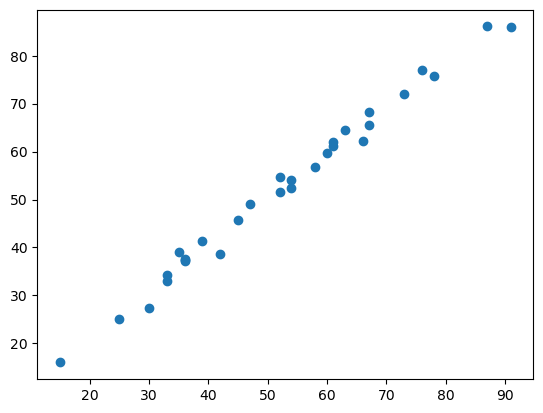

In [36]:
# Create scatter plot to see distribution
plt.scatter(y_test, predict)
plt.show()

In [37]:
# see mean absolute error 
mean_absolute_error(y_test,predict)

1.576666666666667

In [38]:
# see score
r2_score(y_test,predict)

0.9882370862489189

In [39]:
# see coefficients values
model.coef_

array([ 2.91246196,  0.9986716 ,  0.96090243,  0.4619132 ,  0.16919982,
        0.21349922, -0.41503486])

In [40]:
# see y intercept
model.intercept_

-36.89466338604134